In [ ]:
# import necessary packages and libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Import the data

In [109]:
# Load in the dataset
df = pd.read_excel('eletronic_sales.xlsx')

# Data Wrangling

Getting Basic Information on the data


In [110]:
# Checking the first ten rows

df.head(10)
df

,Date,Branch,Sales Agent,Products,Units,Price
0,2014-09-01,Woji,Chinedu,Apple,2,125.00
1,2015-06-17,Woji,Emeka,Apple,5,125.00
2,2015-09-10,Woji,Ibrahim,Lenovo,7,1.29
3,2015-11-17,Woji,Tolu,HP,11,4.99
4,2015-10-31,Woji,Tonye,Lenovo,14,1.29
5,2014-02-26,Woji,Ibrahim,Compaq,27,19.99
6,2014-10-05,Woji,George,HP,28,8.99
7,2015-12-21,Woji,Tonye,HP,28,4.99
8,2014-02-09,Woji,Tolu,Lenovo,36,4.99
9,2015-08-07,Woji,Emeka,Dell,42,23.95


In [111]:
# checking the statistical summary
df.describe()

,Date,Units,Price
count,43,43.000000,43.000000
mean,2014-12-29 00:00:00,49.325581,20.308605
min,2014-01-06 00:00:00,2.000000,1.290000
25%,2014-07-03 12:00:00,27.500000,3.990000
50%,2014-12-29 00:00:00,53.000000,4.990000
75%,2015-06-25 12:00:00,74.500000,17.990000
max,2015-12-21 00:00:00,96.000000,275.000000
std,NaN,30.078248,47.345118


In [112]:
# checking the shape of the file
df.shape

(43, 6)

In [113]:
# Check for the column names
df.columns

Index(['Date', 'Branch', 'Sales Agent', 'Products', 'Units', 'Price'], dtype='object')

In [114]:
# checking for the data type
df.dtypes

Date           datetime64[ns]
Branch                 object
Sales Agent            object
Products               object
Units                   int64
Price                 float64
dtype: object

In [115]:
# checking for missing values
df.isnull().sum()

Date           0
Branch         0
Sales Agent    0
Products       0
Units          0
Price          0
dtype: int64

Feature Engineering

In [116]:
# Create a new column for the monthly revenue

df['Revenue'] = df['Units'] * df['Price']

# To round the monthly revenue to 2 decimal places
# df['Revenue(NGN)'] = round(df['Revenue'], 2)

<Axes: xlabel='Data Types', ylabel='Count'>

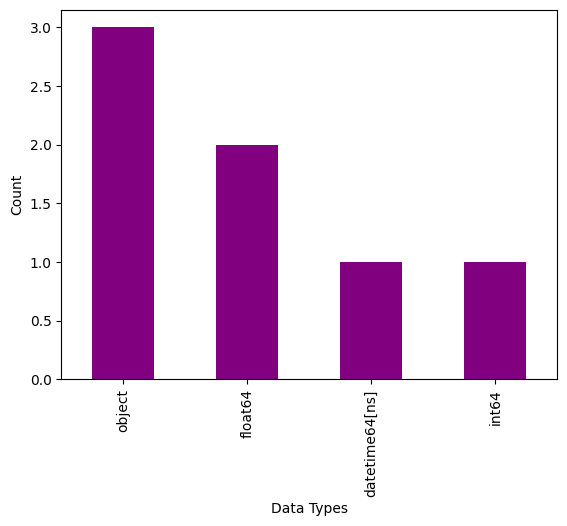

In [117]:
# Visualizing the ratio of the data types
df.dtypes.value_counts().plot(kind='bar', xlabel= 'Data Types', ylabel='Count', color='purple')

In [118]:
# Extract the date, month and year from the datetime

# Extracting the year
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Week'] = df['Date'].dt.day_name()



In [119]:
df.head()

,Date,Branch,Sales Agent,Products,Units,Price,Revenue,Year,Month,Week
0,2014-09-01,Woji,Chinedu,Apple,2,125.00,250.00,2014,September,Monday
1,2015-06-17,Woji,Emeka,Apple,5,125.00,625.00,2015,June,Wednesday
2,2015-09-10,Woji,Ibrahim,Lenovo,7,1.29,9.03,2015,September,Thursday
3,2015-11-17,Woji,Tolu,HP,11,4.99,54.89,2015,November,Tuesday
4,2015-10-31,Woji,Tonye,Lenovo,14,1.29,18.06,2015,October,Saturday


#2.0 Steps to Analysis
**Note:** This is after you have followed the ETL(Extract Transform Load) frame work, this is you importing your dataset, cleaning and preparing it for analysis

### A. Work on the KPI's (Key performance index of this data)
1. Total units sold
2. Total Revenue
3. Average Revenue per unit
4. Numbers of products
5. Numbers of Sales Agents

### B. Work on the insights by creating models(Note that creating models in data analysis is different from building models in machine learning)
1. Total monthly revenue by Year
2. Total revenue by branch
3. Total revenue by products
4. Total revenue by sales agent
5. Total revenue by week
6. Total revenue by month
7. Trends of sales

### C. Build your dash board
1. Add the title of your analysis.
2. Add the business/company
3. Add your KPI's
4. Add Charts with appropriate labelling
5. Add your slicer if you are working with streamlit or excel or PowerBi or Tableau to make your dashboard interactive(if not, exclude it)

### C. Report your insights
1. Start with the an executive summary briefly explaining what you and briefly introducing the KPI's.
2. Explain your insights in a narative and relatable way using your visuals.

### D. Make recommendation
1. What should the business owner to increase monthly sales
2. Which of the brannches should be given more attention
3. Which products should be removed from the stock, which products should be purchased more
4. Which of the sales agents should be given more incentives/promoted to sales managers position



### A. Working on the KPIs

1. Total Units Sold

In [120]:
# Get the total units sold

total_units_sold = df['Units'].sum()
print('The total number of units sold is', total_units_sold, 'units')

The total number of units sold is 2121 units


2. Total Monthly Revenue per year

In [121]:
# Get the total revenue and round it to 2 decimal places
Total_Revenue = round(df['Revenue'].sum(), 2)
print('The total Revenue is NGN', Total_Revenue, 'Kobo')

The total Revenue is NGN 19627.88 Kobo


3. Average Revenue per Units

In [122]:
# Getting the average revenue per units and rounding it to 2 decimal places
average_revenue_per_unit = round(Total_Revenue / total_units_sold, 2)
print('The average revenue per unit is NGN', average_revenue_per_unit, 'Kobo')

The average revenue per unit is NGN 9.25 Kobo


4. Number of products

In [123]:
# Getting the number of products using the nunique() function
number_of_products = df['Products'].nunique()
print('In total, there are', number_of_products, 'products')


In total, there are 5 products


5. Number of Sales Agent


In [124]:
# Getting the total number of Sales Agent
number_of_sales_agent = df['Sales Agent'].nunique()
print('There are currently ',number_of_sales_agent, 'agents working here')

There are currently  11 agents working here


### B. Working on the insights by creating models and plotting their charts

### B. Work on the insights by creating models(Note that creating models in data analysis is different from building models in machine learning)
1. Total monthly revenue by Year
2. Total revenue by branch
3. Total revenue by products
4. Total revenue by sales agent
5. Total revenue by week
6. Total revenue by month
7. Trends of sales

1. **Total Monthly Revenue by Year**

In [125]:
# Set index using the date column
df.set_index('Date', inplace=True)

Generate the total monthly revenue for year 2014

In [126]:
# To do this, I will filter, group and visualize

# First, generate the unique years present in the data

df.Year.unique()

array([2014, 2015], dtype=int32)

In [127]:
# Step 1: Filter the data to get the revenue for year 2014

df_2014 = df[df['Year'] == 2014]
df_2015 = df[df['Year'] == 2015]

In [128]:
# Step 2: Use the .groupby() and .sort_index() to arrange the output of the result by index
total_monthly_revenue_2014 = df_2014.groupby('Month')['Revenue'].sum().sort_index()
total_monthly_revenue_2015 = df_2015.groupby('Month')['Revenue'].sum().sort_index()

print('The total monthly revenue for year 2014 according to each month is:\n', total_monthly_revenue_2014)
print('\nThe total monthly revenue for year 2015 according to each month is:\n', total_monthly_revenue_2015)

The total monthly revenue for year 2014 according to each month is:
 Month
April         448.65
August        174.65
December     1269.69
February      719.37
January      1188.55
July         1676.90
June          988.50
March         167.44
May           512.78
November      778.89
October       827.08
September     505.84
Name: Revenue, dtype: float64

The total monthly revenue for year 2015 according to each month is:
 Month
April         610.38
August       1830.90
December     2018.78
February     1324.96
January       413.54
July          996.33
June          625.00
March         389.43
May           787.57
November       54.89
October      1157.49
September     160.27
Name: Revenue, dtype: float64


In [129]:
# Using the .sort_values to arrange the output according to the price

total_monthly_revenue_for_2014 = df_2014.groupby('Month')['Revenue'].sum().sort_values()
total_monthly_revenue_for_2015 = df_2015.groupby('Month')['Revenue'].sum().sort_values()

print('The total monthly revenue for year 2014 according to price is:\n', total_monthly_revenue_for_2014)
print('\nThe total monthly revenue for year 2015 according to price is:\n', total_monthly_revenue_for_2015)

The total monthly revenue for year 2014 according to price is:
 Month
March         167.44
August        174.65
April         448.65
September     505.84
May           512.78
February      719.37
November      778.89
October       827.08
June          988.50
January      1188.55
December     1269.69
July         1676.90
Name: Revenue, dtype: float64

The total monthly revenue for year 2015 according to price is:
 Month
November       54.89
September     160.27
March         389.43
January       413.54
April         610.38
June          625.00
May           787.57
July          996.33
October      1157.49
February     1324.96
August       1830.90
December     2018.78
Name: Revenue, dtype: float64


<Axes: title={'center': 'Revenue for year 2014'}, xlabel='Month', ylabel='Revenue'>

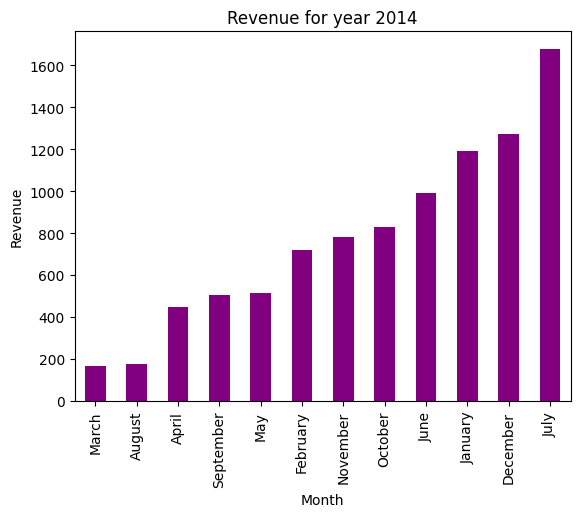

In [130]:
# Visualizing the monthly revenue for 2014 using pandas
total_monthly_revenue_for_2014.plot(kind= 'bar', xlabel = 'Month', ylabel = 'Revenue', title= 'Revenue for year 2014', color='purple')


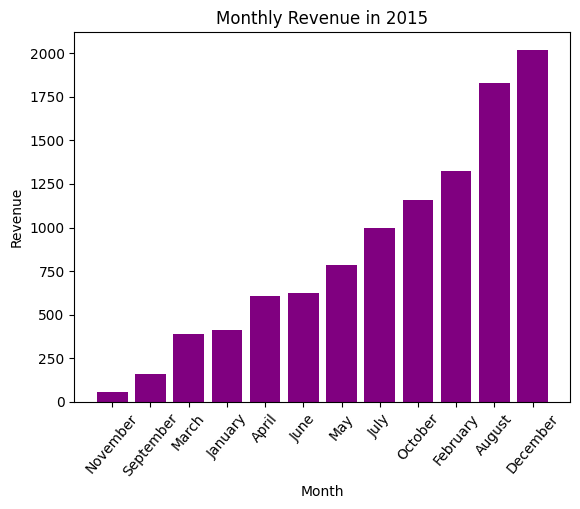

In [131]:
# Using matplotlib to visualize for 2015
plt.bar(total_monthly_revenue_for_2015.index, total_monthly_revenue_for_2015.values, color='purple')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue in 2015')
plt.xticks(rotation = 50)
plt.show()

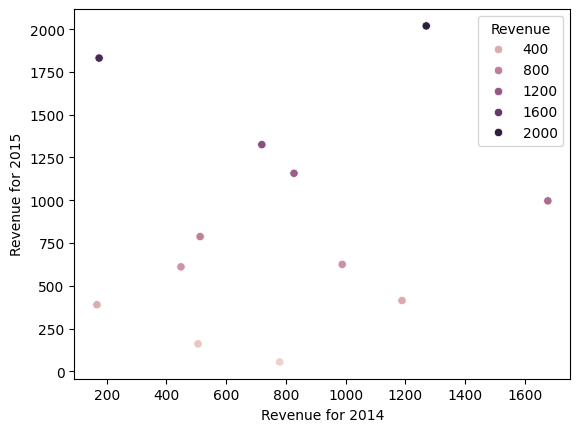

In [132]:
# Using seaborn scatterplot to visualize both years

features = [total_monthly_revenue_for_2014, total_monthly_revenue_for_2015]
sns.scatterplot(x=total_monthly_revenue_for_2014, y=total_monthly_revenue_for_2015, hue= total_monthly_revenue_for_2015)
plt.xlabel("Revenue for 2014")
plt.ylabel("Revenue for 2015")
plt.show()
# sns.barplot(x =total_monthly_revenue.values, y = total_monthly_revenue.index, orient='h', color='purple')

2. **Total Revenue by Branch**

In [133]:
# First check the branches available
df['Branch'].unique()

array(['Woji', 'GRA', 'Town'], dtype=object)

In [134]:
# Sort the revenue by branch in descending order
total_revenue_by_branch = df.groupby('Branch')['Revenue'].sum().sort_values(ascending=False)


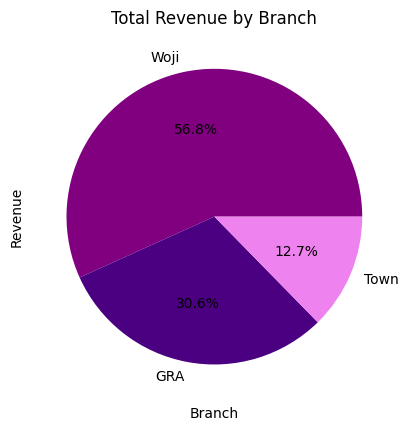

In [135]:
#plot the chart using matplotlib
plt.pie(total_revenue_by_branch.values, labels=total_revenue_by_branch.index, autopct='%1.1f%%', colors=['purple', 'indigo', 'violet'])
plt.xlabel('Branch')
plt.ylabel('Revenue')
plt.title('Total Revenue by Branch')
plt.show()

3. **Total Revenue by Product**

In [136]:
# First check for the unique products present
df['Products'].unique()

array(['Apple', 'Lenovo', 'HP', 'Compaq', 'Dell'], dtype=object)

In [137]:
# Get the total revenue by product
total_revenue_by_product = df.groupby('Products')['Revenue'].sum().sort_values(ascending=False)
print(total_revenue_by_product)

Products
HP        9577.65
Dell      4169.87
Lenovo    2135.14
Compaq    2045.22
Apple     1700.00
Name: Revenue, dtype: float64


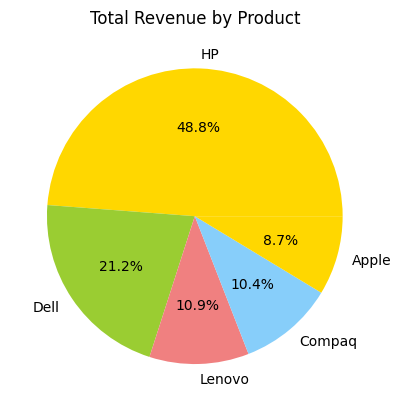

In [138]:
# Plot the visualization using matplotlib

plt.pie(total_revenue_by_product.values, labels=total_revenue_by_product.index, autopct='%1.1f%%', colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue'])
plt.title('Total Revenue by Product')
plt.show()

**4. Total Revenue by Sales Agent**

In [139]:
# First check for the sales agents available

df['Sales Agent'].unique()


array(['Chinedu', 'Emeka', 'Ibrahim', 'Tolu', 'Tonye', 'George',
       'Blessing', 'Chioma', 'Torbari', 'Uche', 'Tunde'], dtype=object)

In [140]:
# Sort the total revenue by sales agents

total_revenue_by_sales_agent = df.groupby('Sales Agent')['Revenue'].sum().sort_values(ascending=False)

<Axes: ylabel='Sales Agent'>

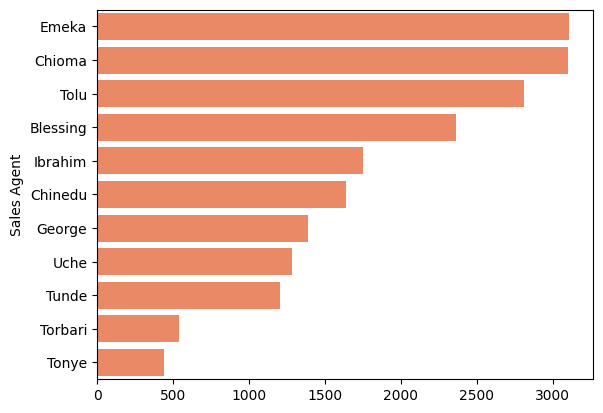

In [141]:
# Plot the chart using seaborn
sns.barplot(x = total_revenue_by_sales_agent.values, y = total_revenue_by_sales_agent.index, orient='h', color='coral')

**5. Total Revenue by Week**

In [ ]:
# Get the total revenue by product

total_revenue_by_week = df.groupby('Weekdays')['Revenue'].sum().sort_values(ascending=False)
print(total_revenue_by_week)

Week
Monday       3515.17
Friday       3426.63
Tuesday      3388.97
Wednesday    3348.58
Sunday       3146.20
Thursday     1809.96
Saturday      992.37
Name: Revenue, dtype: float64


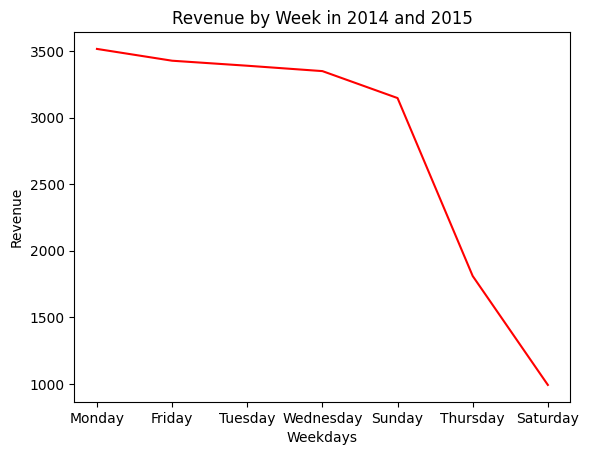

In [175]:
# Plotting the revenue by week using lineplot for both years
plt.plot(total_revenue_by_week.index, total_revenue_by_week.values, color='red')
plt.xlabel('Weekdays')
plt.ylabel('Revenue')
plt.title('Revenue by Week in 2014 and 2015')
plt.show()

<Axes: title={'center': 'Revenue by Week'}, xlabel='Week', ylabel='Revenue'>

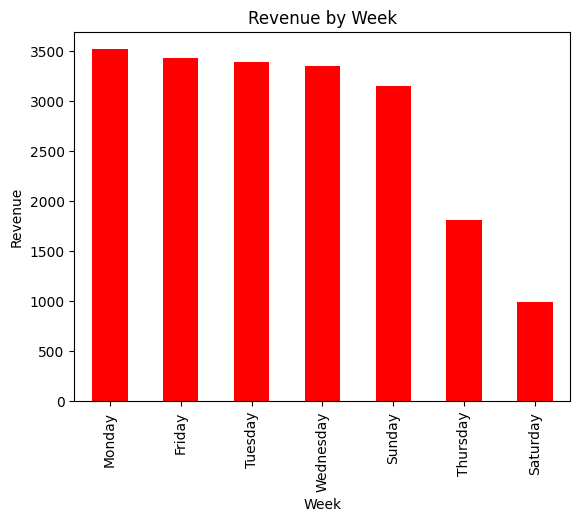

In [ ]:
# Plotting the revenue by week using barplot for both years
total_revenue_by_week.plot(kind='bar', x=total_revenue_by_week.index, y=total_revenue_by_week.values, xlabel = 'Weekdays', ylabel = 'Revenue', title= 'Revenue by Week', color='red')

The revenue generated by week in 2014:
Week
Tuesday      2397.63
Monday       2071.41
Wednesday    1564.19
Thursday     1319.02
Sunday        970.76
Saturday      525.00
Friday        410.33
Name: Revenue, dtype: float64


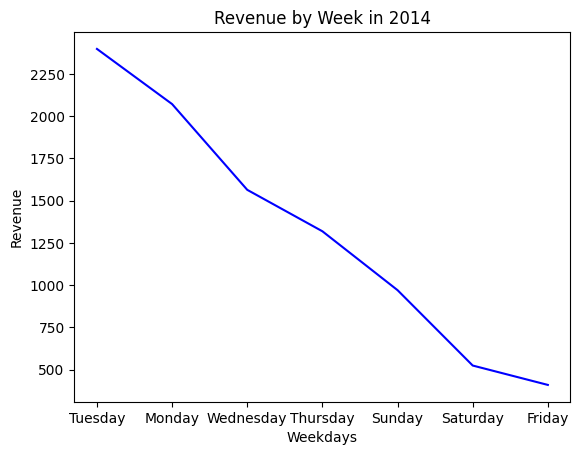

In [174]:
# Sorting the revenue by week for 2014 and plotting using lineplot
revenue_by_week_for_2014 = df_2014.groupby('Week')['Revenue'].sum().sort_values(ascending=False)
print(f"The revenue generated by week in 2014:\n{revenue_by_week_for_2014}")
plt.plot(revenue_by_week_for_2014.index, revenue_by_week_for_2014.values,color='blue')
plt.xlabel('Weekdays')
plt.ylabel('Revenue')
plt.title('Revenue by Week in 2014')
plt.show()

Revenue by Week in 2015:
Week
Friday       3016.30
Sunday       2175.44
Wednesday    1784.39
Monday       1443.76
Tuesday       991.34
Thursday      490.94
Saturday      467.37
Name: Revenue, dtype: float64


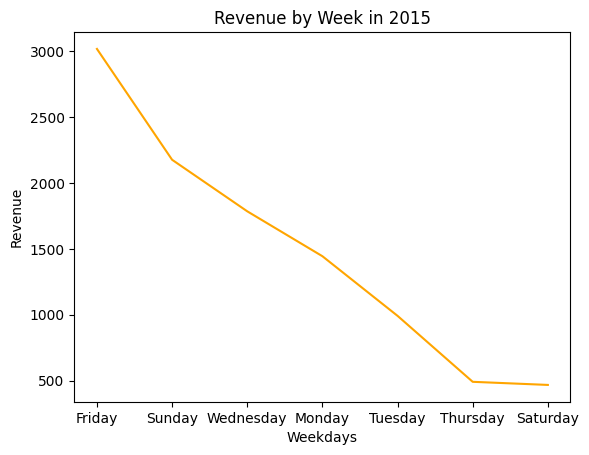

In [173]:
# Sorting the revenue by week for 2015 and plotting using lineplot
revenue_by_week_for_2015 = df_2015.groupby('Week')['Revenue'].sum().sort_values(ascending=False)
print(f"Revenue by Week in 2015:\n{revenue_by_week_for_2015}")
plt.plot(revenue_by_week_for_2015.index, revenue_by_week_for_2015.values, color='orange')
plt.xlabel('Weekdays')
plt.ylabel('Revenue')
plt.title('Revenue by Week in 2015')
plt.show()

**5. Total Revenue by Month**

<Axes: title={'center': 'Revenue by Month'}, xlabel='Month', ylabel='Revenue'>

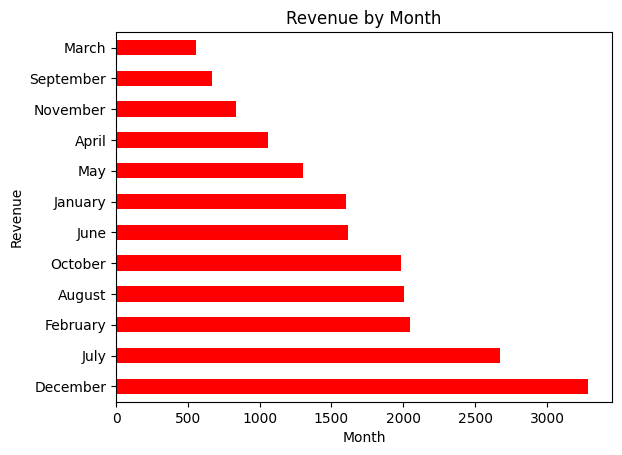

In [152]:
total_revenue_by_month = df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)
total_revenue_by_month.plot(kind='barh', x=total_revenue_by_month.index, y=total_revenue_by_month.values, xlabel = 'Month', ylabel = 'Revenue', title= 'Revenue by Month', color='red')

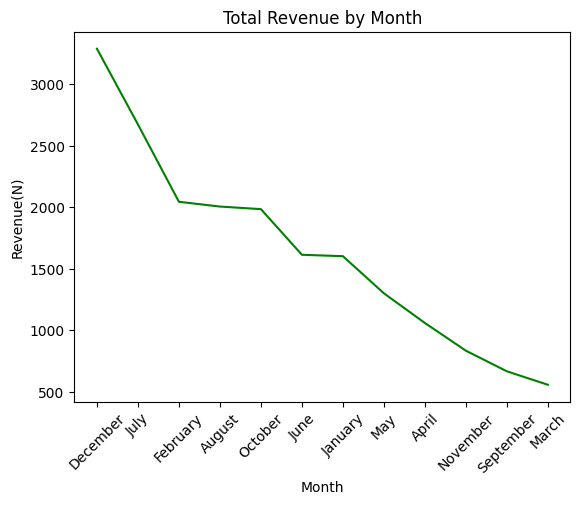

In [172]:
# plot using searborn line chart
sns.lineplot(x = total_revenue_by_month.index, y = total_revenue_by_month.values, color='green')
plt.xlabel("Month")
plt.xticks(rotation = 45)
plt.ylabel("Revenue(N)")
plt.title("Total Revenue by Month")
plt.show()

**Trend of Sales**

The sales trend for 2014:
    Year      Month  Revenue
0   2014      April   448.65
1   2014     August   174.65
2   2014   December  1269.69
3   2014   February   719.37
4   2014    January  1188.55
5   2014       July  1676.90
6   2014       June   988.50
7   2014      March   167.44
8   2014        May   512.78
9   2014   November   778.89
10  2014    October   827.08
11  2014  September   505.84


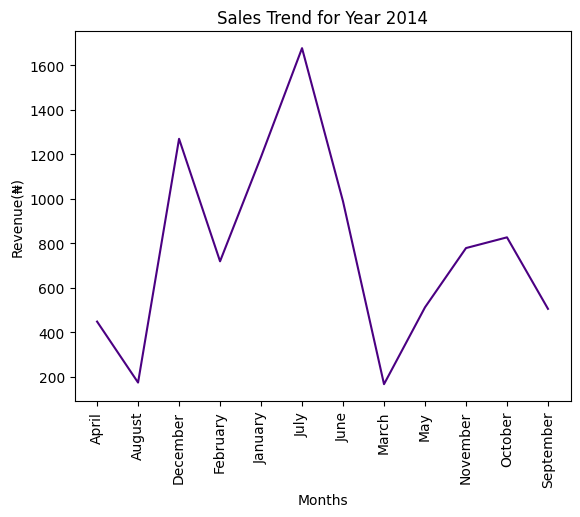

In [180]:
# Checking the sales trend in 2014
total_sales_trend_2014 = df_2014.groupby(['Year','Month'])['Revenue'].sum().reset_index()
print(f"The sales trend for 2014:\n{total_sales_trend_2014}")

# Plotting the sales trend for 2014
plt.plot(total_sales_trend_2014["Month"], total_sales_trend_2014["Revenue"], color='indigo')
plt.xlabel('Months')
plt.ylabel('Revenue(₦)')
plt.xticks(rotation = 90)
plt.title('Sales Trend for Year 2014')
plt.show()

The sales trend for 2015:
    Year      Month  Revenue
0   2015      April   610.38
1   2015     August  1830.90
2   2015   December  2018.78
3   2015   February  1324.96
4   2015    January   413.54
5   2015       July   996.33
6   2015       June   625.00
7   2015      March   389.43
8   2015        May   787.57
9   2015   November    54.89
10  2015    October  1157.49
11  2015  September   160.27


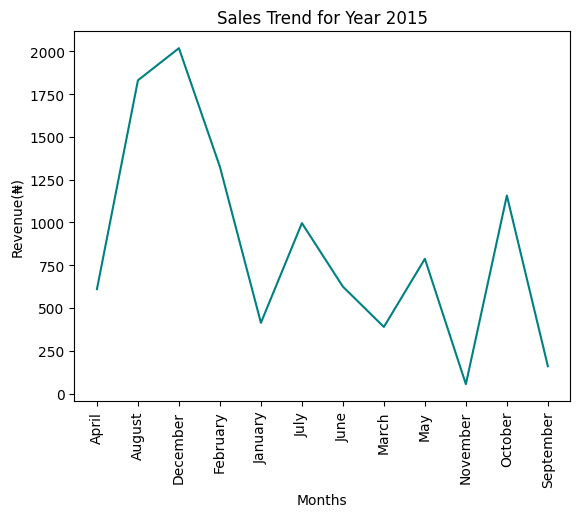

In [181]:
# Checking the sales trend in 2015
total_sales_trend_2015 = df_2015.groupby(['Year','Month'])['Revenue'].sum().reset_index()
print(f"The sales trend for 2015:\n{total_sales_trend_2015}")

# Plotting the sales trend for 2015
plt.plot(total_sales_trend_2015["Month"], total_sales_trend_2015["Revenue"], color='teal')
plt.xlabel('Months')
plt.ylabel('Revenue(₦)')
plt.xticks(rotation = 90)
plt.title('Sales Trend for Year 2015')
plt.show()

In [182]:
#6. Trends of sales
trends_of_sales = df.groupby(["Year","Month"])["Revenue"].sum().reset_index().sort_values(by=["Year","Month"], ascending=False)
trends_of_sales

,Year,Month,Revenue
23,2015,September,160.27
22,2015,October,1157.49
21,2015,November,54.89
20,2015,May,787.57
19,2015,March,389.43
18,2015,June,625.00
17,2015,July,996.33
16,2015,January,413.54
15,2015,February,1324.96
14,2015,December,2018.78


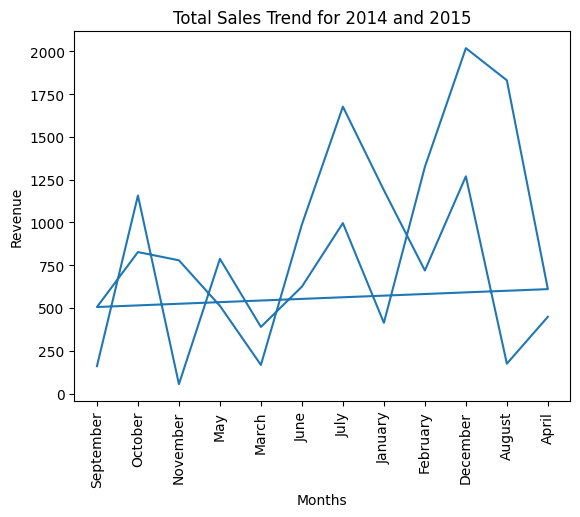

In [184]:
# Visualizing for both years using pandas
plt.plot(trends_of_sales["Month"], trends_of_sales["Revenue"])
plt.xlabel('Months')
plt.ylabel('Revenue')
plt.xticks(rotation = 90)
plt.title('Total Sales Trend for 2014 and 2015')
plt.show()

In [186]:
# Save the cleaned data for future reference
df.to_excel('cleaned_electronic_sales_data.xlsx', index=True)